In [1]:
%reload_ext autoreload
%autoreload 2

import os
import sys

import jax
import jax.numpy as jnp

import numpy as np
import healpy as hp
import pickle
from tqdm import tqdm

os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"
print(jax.devices())

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file('../notebooks/matplotlibrc')

[gpu(id=0)]


## toy templates

In [2]:
nside = 4
npix = hp.nside2npix(nside)
print(npix)

regen_temps = False
if regen_temps:
    for i in range(5):
        z = np.random.uniform(size=npix)
        np.save(f'temp_{i}.npy', z)

192


## simulate

In [3]:
sys.path.append("..")
from simulations.wrapper import toy_simulator

/n/home07/yitians/fermi/fermi-prob-prog/npll_issue/../simulations/simulate_ps.py:9: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [4]:
vd_base = dict(
    Sps_t0 = None,
    Sps_t1 = None,
    n1_t0 = 5.0, n2_t0 = 1.3, n3_t0 = -5.4, sb1_t0 = 11., lambdas_t0 = 0.4,
    n1_t1 = 5.5, n2_t1 = 1.5, n3_t1 = -5.5, sb1_t1 = 7.6, lambdas_t1 = 0.3,
)

In [5]:
temps = [np.load(f'temp_{i}.npy') for i in range(5)]
for t in temps:
    t /= np.mean(t)

In [9]:
include_temps = [0]

save_dir = 'sim_t' + ''.join([str(i) for i in include_temps])
os.makedirs(save_dir, exist_ok=True)
vd = vd_base.copy()
vd['Sps_t0'] = 3.
vd['Sps_t1'] = 0.
pickle.dump(vd, open(f"{save_dir}/truth.p", 'wb'))

In [10]:
# simulate
for i in tqdm(range(100)):
    counts = toy_simulator(temps, vd, delta_psf=True)
    np.save(f"{save_dir}/counts_{i}.npy", np.array(counts, dtype=np.int32))

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:18<00:00,  5.31it/s]


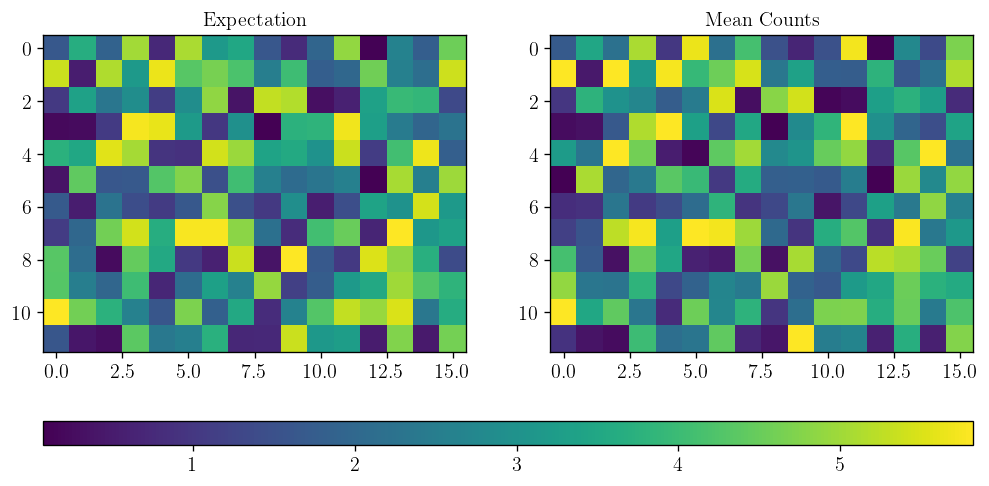

In [11]:
mean_counts = np.zeros_like(counts)
for i in range(100):
    mean_counts += np.load(f"{save_dir}/counts_{i}.npy")
mean_counts /= 100

expectation = np.zeros_like(counts)
for i in range(5):
    if f'Sps_t{i}' in vd:
        expectation += temps[i] * vd[f'Sps_t{i}']

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
vmin, vmax = np.min(expectation), np.max(expectation)
axs[0].imshow(expectation.reshape(12, 16), vmin=vmin, vmax=vmax)
im = axs[1].imshow(mean_counts.reshape(12, 16), vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axs, orientation='horizontal', aspect=40)
axs[0].set_title('Expectation')
axs[1].set_title('Mean Counts');